In [7]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
data0 = pd.read_csv('dataset.csv')
data = data0.copy()
data.head()

,NumHAcceptors,NumHDonors,alkyl_num,frag_sym,HOMO_calc,LUMO_calc,dipole,MPI,surface_min,surface_max,...,anchor_end_PO,anchor_end_SA,anchor_end_SH,anchor_end_SiO,MetalOxide_ITO,MetalOxide_NiOx,MetalOxide_SnO2,MetalOxide_TiO2,MetalOxide_ZnO,PCE
0,2,2,2,1,-5.665071,-1.022318,1.975439,11.42494,-38.62844,53.933991,...,0,0,0,0,0,1,0,0,0,22.40
1,4,2,2,1,-5.146211,-1.007550,1.467697,12.11600,-39.79595,52.674270,...,0,0,0,0,0,1,0,0,0,21.00
2,4,2,4,1,-5.182687,-1.386859,2.954174,12.05384,-40.46879,51.108000,...,0,0,0,0,0,1,0,0,0,25.60
3,3,1,0,0,-8.070575,-1.975575,6.131034,17.92665,-35.95829,45.147690,...,0,1,0,0,0,0,0,1,0,16.54
4,3,1,0,0,-7.655580,-1.919355,3.424702,15.53109,-31.70790,57.597300,...,0,1,0,0,0,0,0,1,0,16.88


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = data.iloc[:,:-1]
y = data.iloc[:,-1] - data['control_PCE']
x = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

In [9]:
# Xgboost and SHAP
import xgboost as xgb

xgb_model = xgb.sklearn.XGBRegressor(learning_rate=0.038720219063009105,
                                     n_estimators=146,
                                     max_depth=5,
                                     min_child_weight=3,
                                     subsample=0.48056522059460005,
                                     colsample_bytree=0.5838892355234521,
                                     gamma=0.1510151427606958,
                                     reg_alpha=0.28441318923438275,
                                     reg_lambda=0.31148782627614213,
                                     objective='reg:squarederror',
                                     seed=0)
xgb_model.fit(x, y)
print(f"RMSE: {np.sqrt(mean_squared_error(y, xgb_model.predict(x)))}")
print(f"r: {stats.pearsonr(y, xgb_model.predict(x))[0]}")


RMSE: 0.5315024071193554
r: 0.9517045958378145


d:\anaconda3\envs\rdkit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(175, 27)


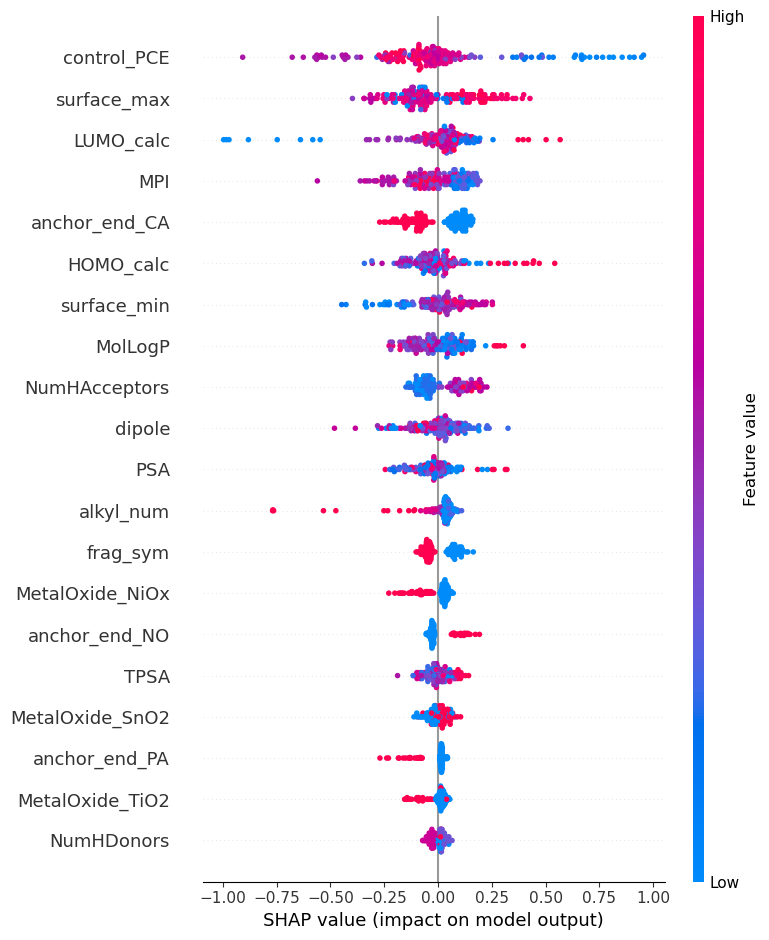

In [10]:
import shap
rf_exp = shap.TreeExplainer(xgb_model)
shap_xgb = rf_exp.shap_values(x)
print(shap_xgb.shape)

shap.summary_plot(shap_xgb,x,show=False)
plt.rcParams.update({
                'figure.figsize': (10, 12),
                'font.size': 8,
                'axes.titlesize': 8,
                'axes.labelsize':8,
                'lines.linewidth':0.75,
                'font.family': 'Helvetica',
                'pdf.fonttype': 42,
                'ps.fonttype': 42,
                'svg.fonttype': 'none',
                'figure.dpi': 300,
            })
ax = plt.gca()
ax.tick_params()
plt.show()

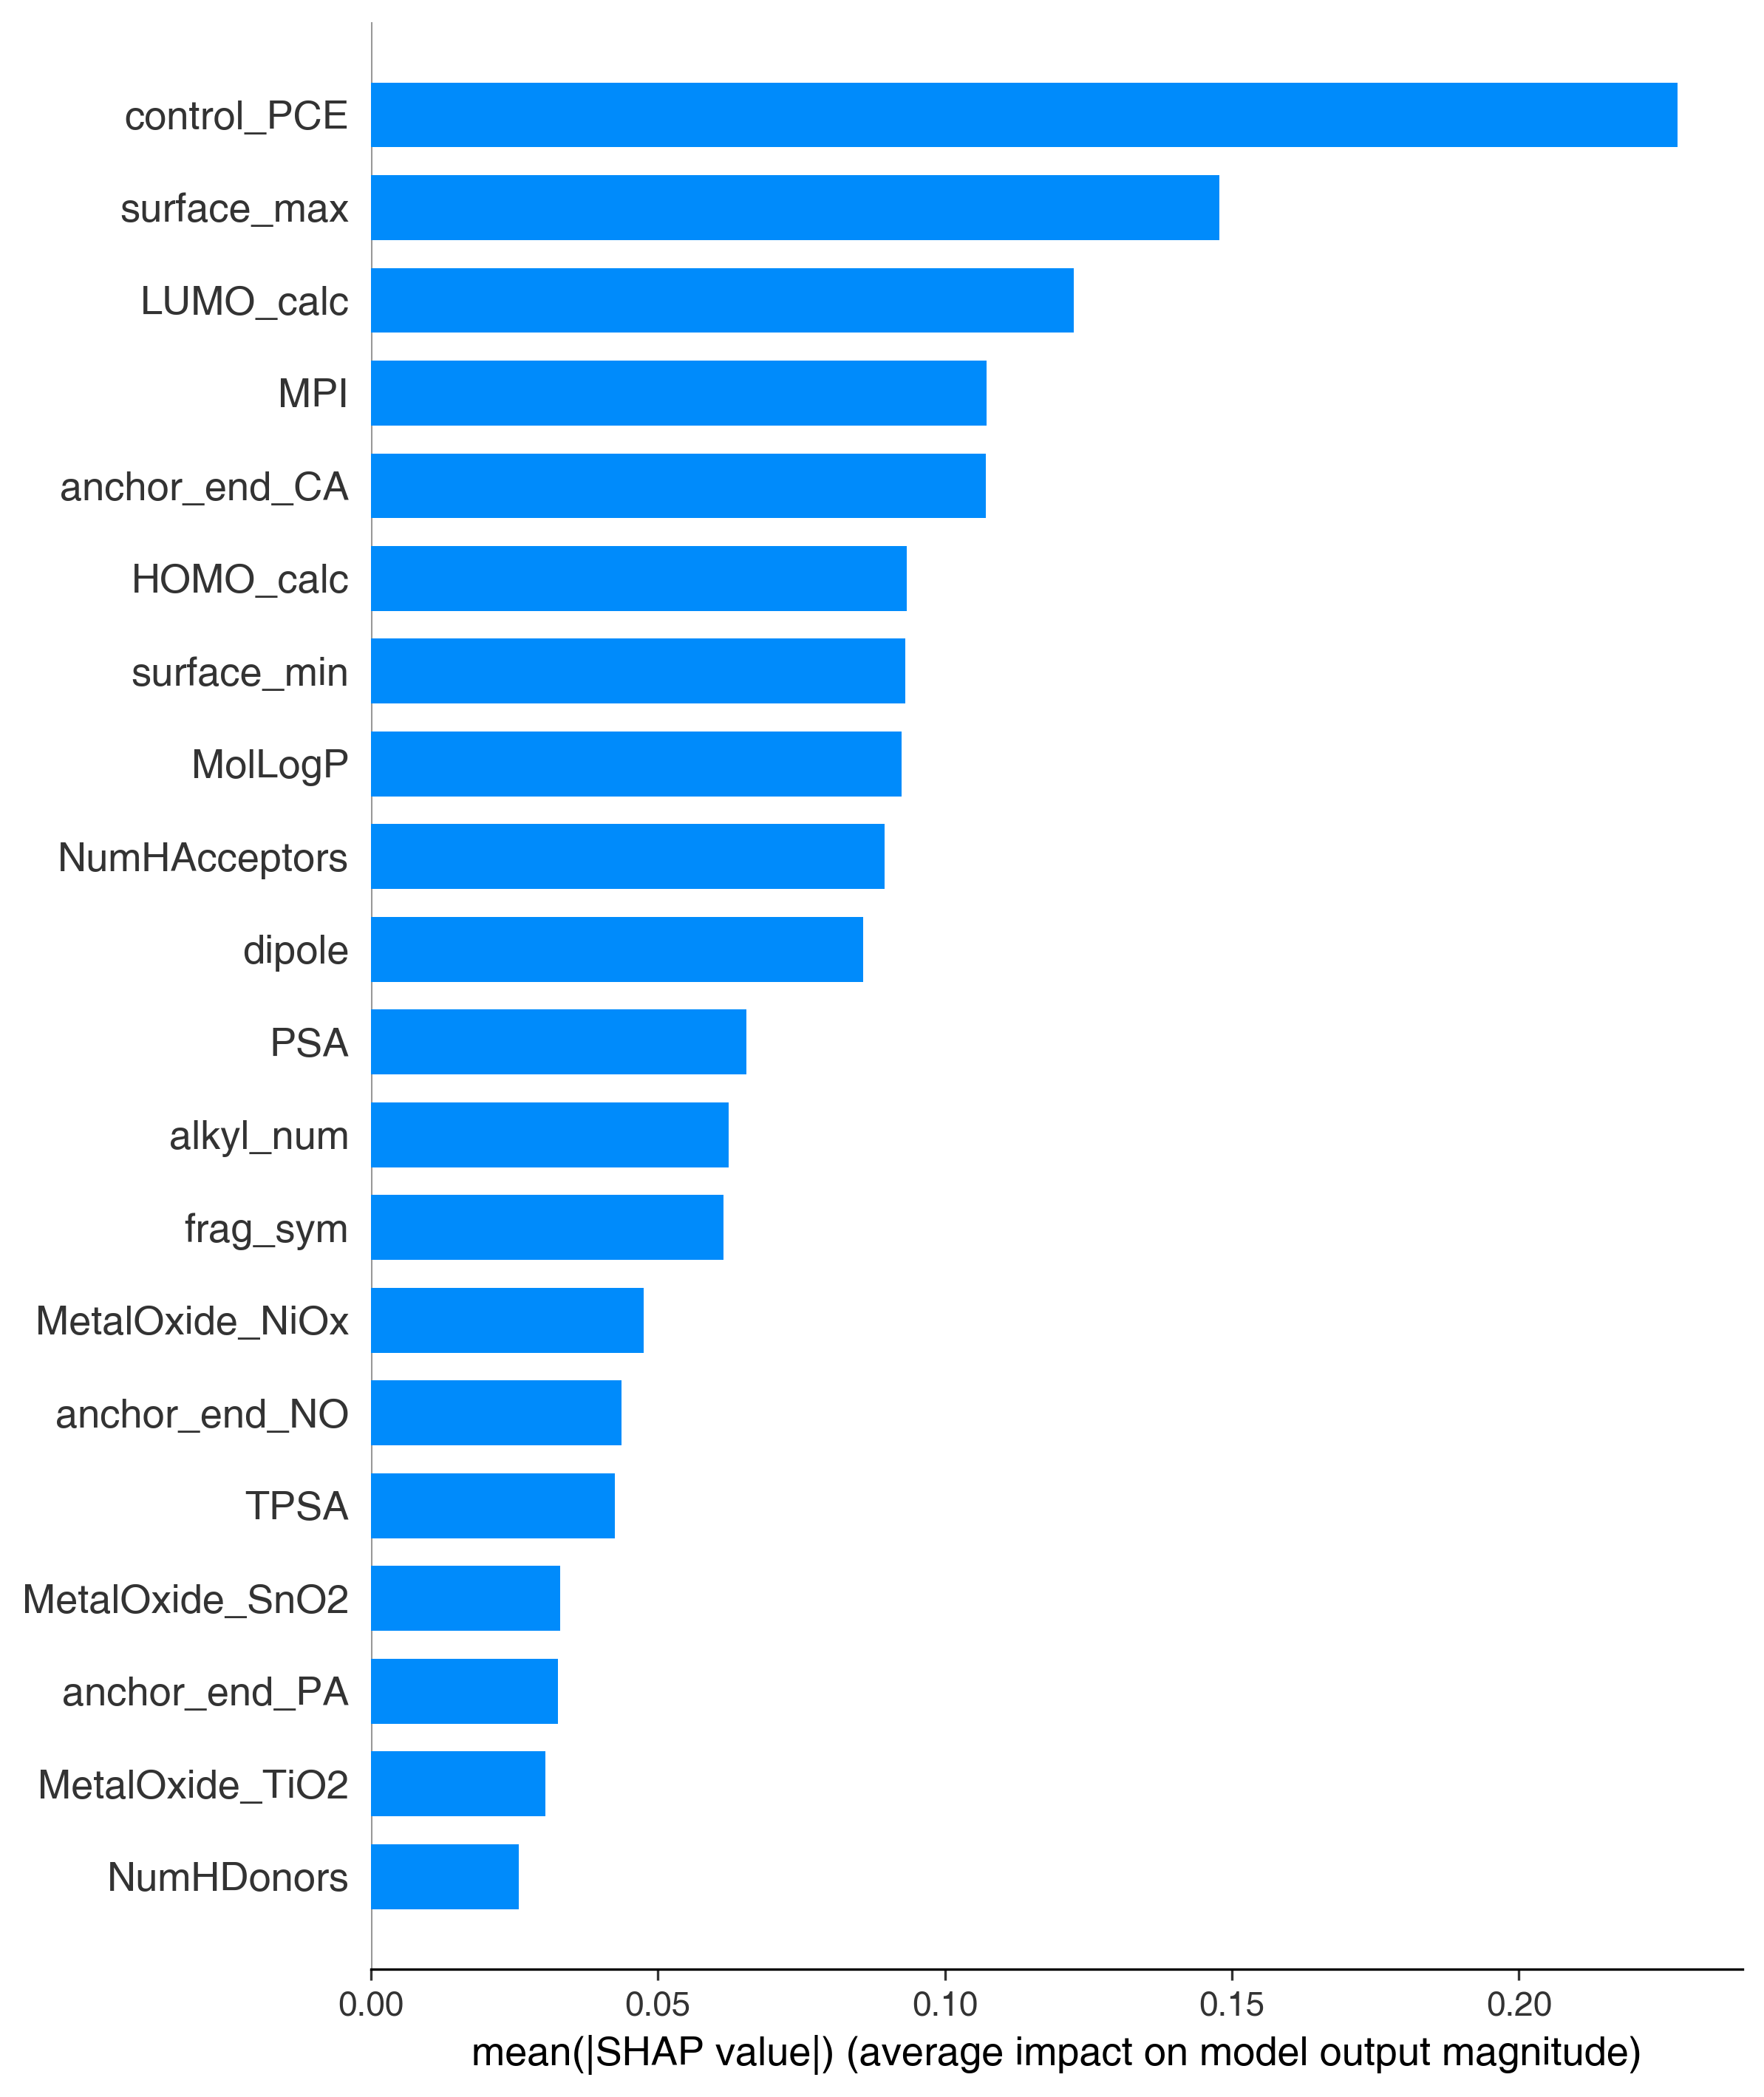

[0.0895118  0.02578169 0.06232861 0.06145633 0.09330206 0.12243233
 0.08578454 0.10727781 0.09308396 0.14785434 0.04257809 0.09252018
 0.06536694 0.22755899 0.00294265 0.10716958 0.04368025 0.03261171
 0.         0.00364648 0.         0.0008115  0.         0.04757595
 0.03299108 0.03039608 0.00941426]


In [11]:
shap.summary_plot(shap_xgb, x, plot_type="bar",show=False)
plt.show()
abs_shapvalue = abs(shap_xgb)
shap_average = np.average(abs_shapvalue,axis=0)
print(shap_average)